In [1]:
%load_ext autoreload
%autoreload 2

****************************************
# Galactic: Crab Analysis (DC1)

This notebook analyzes the Crab source using both the **DC1-style Crab simulation** and the newer **DC2 Crab simulation**.

The purpose is to compare the two analysis cases within the DC2 framework while reusing a familiar source.

For **Crab DC1**, the goals are to:

- Localize the source
- Measure the spectrum
- Reconstruct an image of the source

For **Crab DC2**, the goal is to:

- Detect the source
- Measure the phase-integrated spectrum

The DC2 Crab simulation includes the combined **pulsar + nebula spectrum**, divided into five energy bands from **100 keV to 10 MeV**. 
**************

## Contents

- [Setup](#toc-setup)
  - [Imports](#toc-imports)
  - [Data](#toc-data)
  - [Inputs](#toc-inputs)
- [Binning the Data](#toc-binning-data)
  - [DC1, DC2 & Background Binning](#toc-background-binning)
  - [Exploring Raw Binned Data](#toc-exploring-binned-data)
- [Detector Response & Signal Expectation](#toc-detector-signal)
  - [Detector Response](#toc-detector-response)
  - [Point Source Response](#toc-point-source-response)
  - [Point Source Response in Inertial Coordinates](#toc-inertial-response)
- [Challenge 2 - Crab](#toc-challenge-crab)
    - [DC1 Goal 3 - Localization TS Map](#toc-localization)
    - [DC1 Goal 2 - Measure the Crab Spectrum](#toc-dc1-spectrum)
    - [DC1 Goal 3 - Image the Crab](#toc-dc1-imaging)

***

<a id="toc-setup"></a>
## set up

<a id="toc-imports"></a>
### imports

In [ ]:
from pathlib import Path
import sys

# Locate the repository whether the notebook starts from the repository root
# or from the notebooks directory.
working_directory = Path.cwd()
repo_root = (
    working_directory.parent
    if working_directory.name == "notebooks"
    else working_directory
)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# General imports
import numpy as np
import matplotlib.pyplot as plt
import mhealpy as hp
from mhealpy import HealpixBase, HealpixMap
import h5py

# COSI imports
import cosipy as cp
from cosipy.statistics import PoissonLikelihood
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.image_deconvolution import DataIF_COSI_DC2, ImageDeconvolution


# Spacecraft information imports
from scoords import SpacecraftFrame

# Other scientific imports
import astropy.units as u
from astropy.coordinates import SkyCoord
from threeML import Band, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw
from histpy import Histogram
from astropy.io import fits
from healpy import mollview

%matplotlib inline


<a id="toc-data"></a>
### data

Define file names

In [ ]:
data_dir = Path(repo_root, "data")

data_crab_dc1 = data_dir / "data-products/downloads/crab_3months_unbinned_data.fits.gz"
data_orientation = data_dir / "data-products" / "downloads" / "20280301_3_month_with_orbital_info.fits"
data_galactic_response = data_dir / "data-products/downloads/psr_gal_DC2.h5"

data_response = data_dir / (
    "data-products/downloads/"
    "SMEXv12.Continuum.HEALPixO3_10bins_log_flat."
    "binnedimaging.imagingresponse.h5"
)

data_background = data_dir / "backgrounds/downloads/total_bg_3months_unbinned_data.fits.gz"

# Paths to the binned data files
crab_dc1_binned = repo_root / "data" / "data-products" / "binned" / "crab_binned_data_dc1.hdf5"
background_binned = repo_root / "data" / "backgrounds" / "binned" / "background_binned_data.hdf5"


In [5]:

# Checking the contents of the FITS file for YAML file creation
with fits.open(data_crab_dc1) as hdul:
    hdul.info()
    print(hdul[1].columns.names)
    # Checking the time range of the data
    times = hdul[1].data["TimeTags"]
# Obtaining the minimum and maximum time values from the TimeTags column
print('tmin:', times.min(), 'tmax:', times.max())

Filename: /Users/maura/Documents/COSI/data-challenge-2/data/data-products/downloads/crab_3months_unbinned_data.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     46   6432442R x 11C   [D, D, 2D, 2D, 2D, D, D, D, D, D, D]   
['Energies', 'TimeTags', 'Xpointings (glon,glat)', 'Ypointings (glon,glat)', 'Zpointings (glon,glat)', 'Phi', 'Chi local', 'Psi local', 'Distance', 'Chi galactic', 'Psi galactic']
tmin: 1835487684.5801868 tmax: 1843466661.583874


<a id="toc-inputs"></a>
### Inputs

In [6]:
# Crab Galactic coordinates
l_crab = 184.55746
b_crab = -5.78436

# Localization spectrum parameters
localization_index = -3.0
localization_K = 1e-3 / u.cm**2 / u.s / u.keV
localization_piv = 100.0 * u.keV

# DC1 Band-spectrum initial parameters
# We will use these values for the spectral heating 
dc1_alpha_initial = -1.99
dc1_beta_initial = -2.32

dc1_E0_initial = (
    531.0
    * (dc1_alpha_initial - dc1_beta_initial)
    * u.keV
)

dc1_xp_initial = (
    dc1_E0_initial
    * (dc1_alpha_initial + 2)
    / (dc1_alpha_initial - dc1_beta_initial)
)

dc1_piv = 500.0 * u.keV
dc1_K_initial = 3.07e-5 / u.cm**2 / u.s / u.keV

***
<a id="toc-binning-data"></a>
## Binning the Data

<a id="toc-background-binning"></a>
### DC1, DC2 & background binning

In [ ]:
# In this part, it seems that it read the intups.yaml (this is the file that contains the inputs for the analysis.)
# In data-challenge-1 this was done in the notebook, but in data-challenge-2 it is done in the inputs.yaml file. (automated)
analysis1 = cp.BinnedData("inputs.yaml")
analysisbg = cp.BinnedData("inputs.yaml")



In [ ]:
# Create the bins if the binned data files do not exist yet

if not crab_dc1_binned.exists():
    analysis1.get_binned_data(
        unbinned_data=str(data_crab_dc1),
        output_name=str(crab_dc1_binned.with_suffix(""))
    )


# Always load the existing/generated files into the objects
analysis1.load_binned_data_from_hdf5(
    binned_data=str(crab_dc1_binned)
)

analysisbg.load_binned_data_from_hdf5(
    binned_data=str(background_binned)
)

In [ ]:
# Since we loaded the binned data from the HDF5 files, we can now get the binning information for each analysis object
analysis1.get_binning_info()
analysisbg.get_binning_info()

In [ ]:
# are our data files created?
print("Crab DC1 binned data exists:", crab_dc1_binned.exists())
print("Background binned data exists:", background_binned.exists())

Crab DC1 binned data exists: True
Crab DC2 binned data exists: True
Background binned data exists: True


<a id="toc-exploring-binned-data"></a>
### Exploring raw binned data: File shape & plots

In [11]:
# lets see the shape of the binned data
print("Crab DC1 binned data shape:", analysis1.binned_data.shape)
print("Crab DC2 binned data shape:", analysis2.binned_data.shape)
print("Background binned data shape:", analysisbg.binned_data.shape) 

Crab DC1 binned data shape: (1108, 10, 36, 768)
Crab DC2 binned data shape: (1108, 10, 36, 768)
Background binned data shape: (1108, 10, 36, 768)


In [12]:
# Inspect the bin centers, edges, and widths for time and energy
print("Time centers:", analysis1.time_bin_centers)
print("Time widths:", analysis1.time_bin_widths)

print("Energy centers:", analysis1.energy_bin_centers)
print("Energy edges:", analysis1.energy_bin_edges)
print("Energy widths:", analysis1.energy_bin_widths)

Time centers: [1.83549129e+09 1.83549849e+09 1.83550569e+09 ... 1.84344866e+09
 1.84345586e+09 1.84346306e+09] s
Time widths: [7201.24278307 7201.24278307 7201.24278331 ... 7201.24278331 7201.24278307
 7201.24278307] s
Energy centers: [ 129.2445  204.839   324.648   514.532   815.4785 1292.445  2048.39
 3246.48   5145.32   8154.785 ] keV
Energy edges: [  100.      158.489   251.189   398.107   630.957  1000.     1584.89
  2511.89   3981.07   6309.57  10000.   ] keV
Energy widths: [  58.489   92.7    146.918  232.85   369.043  584.89   927.    1469.18
 2328.5   3690.43 ] keV


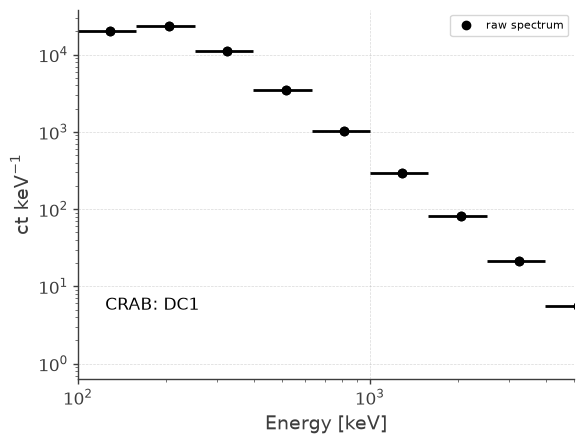

In [13]:
# Plot the raw spectrum for DC1
# We first add text in the plot indicating "Crab: DC1"
fig, ax = plt.subplots()
ax.text(0.15, 0.2, 'CRAB: DC1', transform=ax.transAxes, ha='center', va='center')
analysis1.get_raw_spectrum(show_plots=True
)


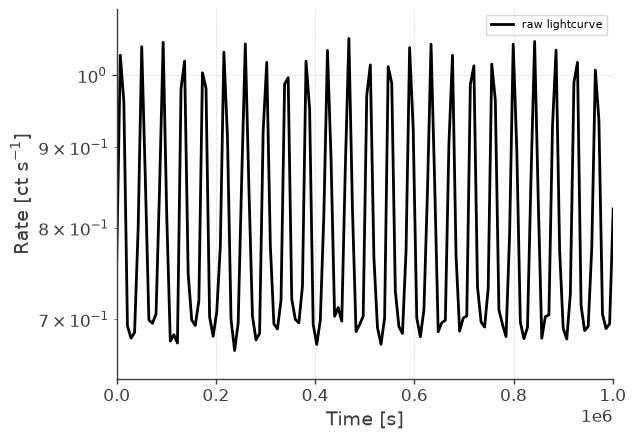

In [14]:
# Plotting DC1 lightcurve
plt.figure()
plt.xlim(0, 1e6)
analysis1.get_raw_lightcurve(show_plots=True)

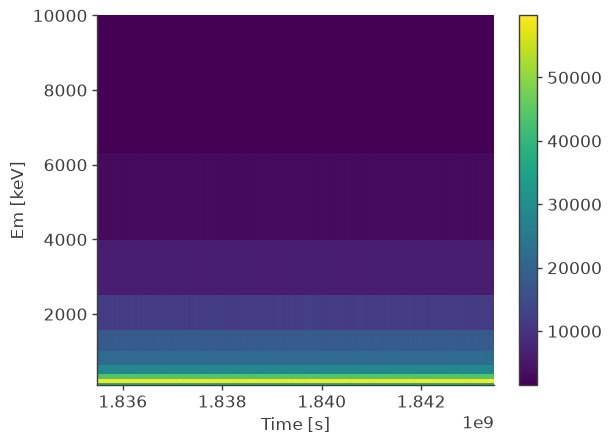

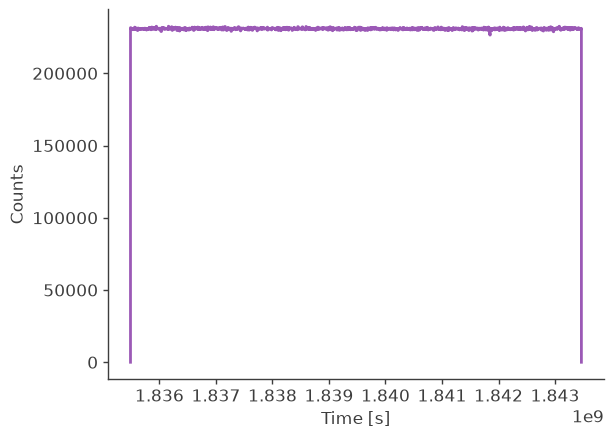

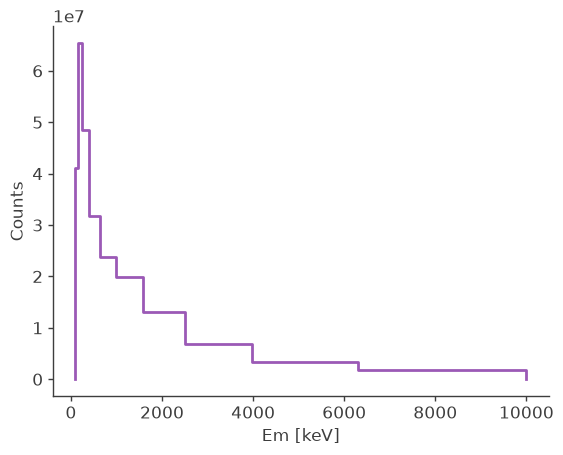

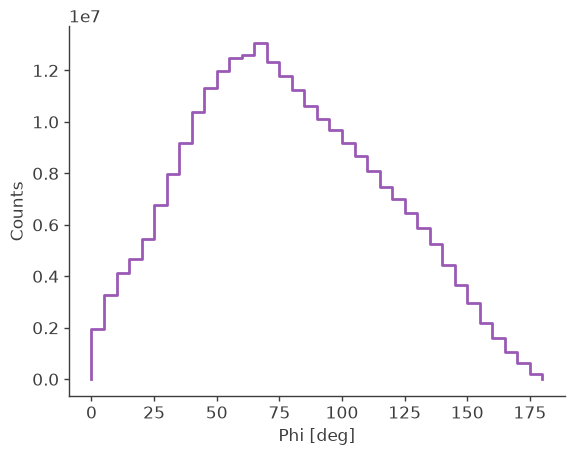

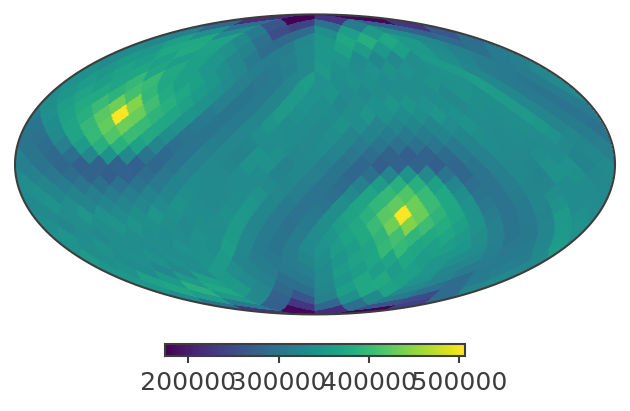

In [15]:
# Plot the binned data projected onto each axis
analysisbg.plot_binned_data(show_plots=True,save_plots = False)

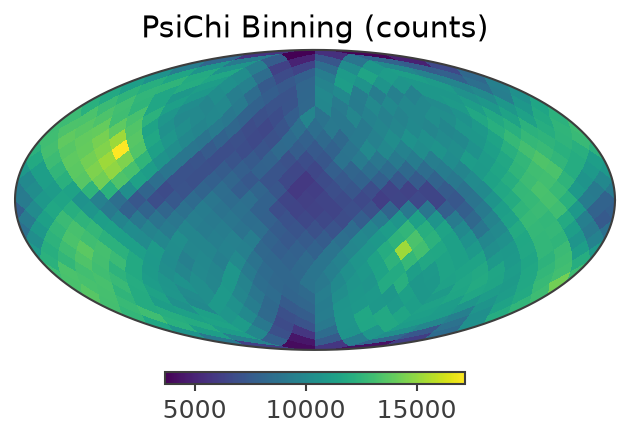

In [16]:
# Plot the event distribution in PsiChi coordinates
analysis2.plot_psichi_map(show_plots=True,save_plots=False)

*******
<a id="toc-detector-signal"></a>
## Detector response & signal expectation

<a id="toc-detector-response"></a>
###  Detector response

In [17]:
# Open and inspect the detector response
# Combine the detector response with the Crab exposure to build its observation-specific response.
# The PSR describes how photons from the Crab would be recorded by COSI.
with cp.response.FullDetectorResponse.open(data_response) as response:
    print("Response axes:", response.axes.labels)
    print('----------------------------------------------------------------')
    print('------------------------- Description --------------------------')
    print('----------------------------------------------------------------')
    print(repr(response))
    print('----------------------------------------------------------------')
    print('')
    print(f"NSIDE = {response.nside}")
    print(f"SCHEME = {response.scheme}")
    print(f"NPIX = {response.npix}")
    print(f"Pixel size = {np.sqrt(response.pixarea()).to(u.deg):.2f}")
    print('')
    print('----------------------------------------------------------------')
    

Response axes: ['NuLambda' 'Ei' 'Em' 'Phi' 'PsiChi']
----------------------------------------------------------------
------------------------- Description --------------------------
----------------------------------------------------------------
FILENAME: '/Users/maura/Documents/COSI/data-challenge-2/data/data-products/downloads/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 768
    NSIDE: 8
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1

In [ ]:
# Inspect the detector response for one fixed direction in the COSI frame.
# A sky-fixed source moves in this frame as COSI rotates, so its final
# point-source response must include the spacecraft attitude history.


with cp.response.FullDetectorResponse.open(data_response) as response:

    drm = response.get_interp_response(SkyCoord(lon = 0*u.deg, lat = 90*u.deg, frame = SpacecraftFrame()))

(<Axes: xlabel='Ei [keV]', ylabel='Em [keV]'>,
 <matplotlib.collections.QuadMesh at 0x1275b8f50>)

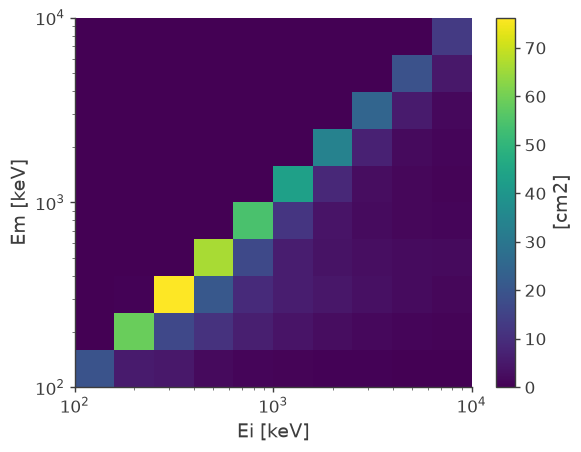

In [19]:
# effective area and the energy dispersion matrix. 
# The effective area can also be evaluated at a specific energy of interest:
# e.g.  drm.get_effective_area(energy_of_interest)
drm.get_spectral_response().plot()

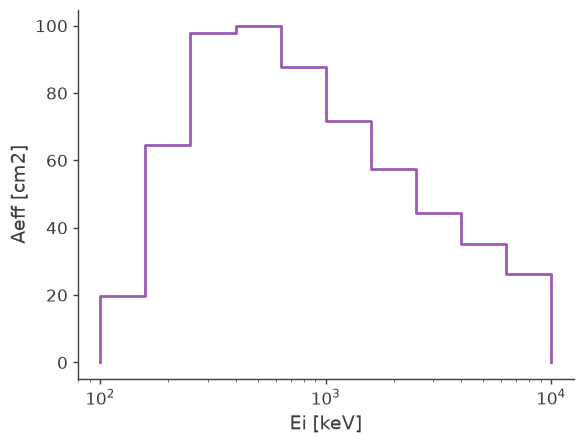

In [20]:
# The effective area can also be evaluated at a specific energy of interest:
# drm.get_effective_area(energy_of_interest)
ax,plot = drm.get_effective_area().plot();

ax.set_ylabel(f'Aeff [{drm.unit}]');

<a id="toc-point-source-response"></a>
### Point source response

In [21]:
# Load the space craft orientation history
orientation = cp.SpacecraftHistory.open(data_orientation)

# Define the target coordinates (Crab)
target_coord = SkyCoord(l_crab, b_crab, unit = 'deg', frame = "galactic")

#-----------------------------------------------------------------------------------
# Build a dwell-time map for the Crab using COSI's orientation history.          
# It records how long the Crab was observed from each direction relative to COSI,
# so the detector response can later be averaged over the full observation.
#-----------------------------------------------------------------------------------
with cp.response.FullDetectorResponse.open(data_response) as response:
    dwell_time_map = orientation.get_dwell_map(target_coord = target_coord, base = response)

In [ ]:
with cp.response.FullDetectorResponse.open(data_response) as response:
    psr = response.get_point_source_response(
        exposure_map=dwell_time_map,
        coord=target_coord,
    )

In [23]:
# Define a trial Crab spectrum: F(E) = K * (E / piv)**index.
# These parameters are an initial hypothesis, not values measured from the data.

index = -1
K = 10**-3 / u.cm / u.cm / u.s / u.keV
piv = 100 * u.keV

spectrum = Powerlaw()
spectrum.index.value = index
spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

# Fold the trial spectrum through the PSR to predict the counts COSI would measure.
expectation = psr.get_expectation(spectrum)

Text(0, 0.5, 'Expected counts')

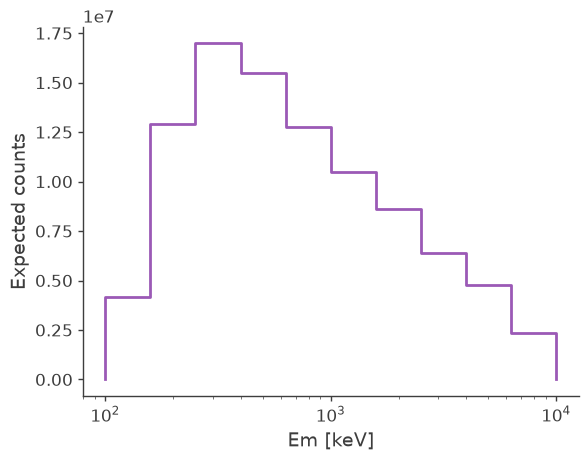

In [24]:
# Project the prediction onto measured energy (Em); this is not the observed spectrum yet.
ax, plot = expectation.project('Em').plot()

ax.set_ylabel('Expected counts')

<a id="toc-inertial-response"></a>
### Point source response in inertial coordinates

Here, we include COSI's changing orientation to build the Crab response in Galactic coordinates.

In [25]:
# Track how long COSI spent in each orientation during the observation.
# This allows the detector response to be rotated into inertial coordinates.
scatt_map = orientation.get_scatt_map(nside = 16, earth_occ = False)


In [26]:
# Build the Crab response in Galactic coordinates using the spacecraft attitude history.
coord = SkyCoord.from_name('Crab').galactic

with cp.response.FullDetectorResponse.open(data_response) as response:
    psr = response.get_point_source_response(coord = coord, scatt_map = scatt_map)

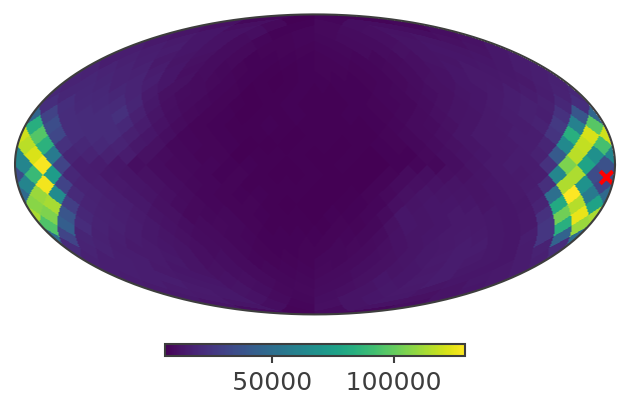

In [27]:
# Select one energy and Compton-angle bin, then project the PSR onto the sky.
# The red marker shows the known Galactic position of the Crab.
psichi_slice = psr.slice[{'Ei':4, 'Phi':4}].project('PsiChi')

ax,plot = psichi_slice.plot(ax_kw = {'coord':'G'})

ax.scatter([coord.l.deg], [coord.b.deg], transform = ax.get_transform('world'), marker = 'x', color = 'red')


Text(0, 0.5, 'Expected counts')

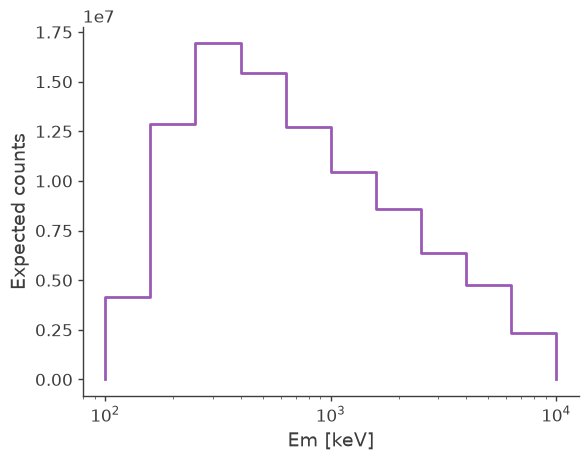

In [28]:
expectation = psr.get_expectation(spectrum)

ax, plot = expectation.project('Em').plot()

ax.set_ylabel('Expected counts')

*****
<a id="toc-challenge-crab"></a>
## Challenge 2 - Crab

**Goals:** <br />
1) Localize source.
2) Measure spectrum.
3) Image source.

The observed counts, source response, background model, and 3ML likelihood
interface are prepared first. The following goal sections then use the
components required by their specific scientific task.


### Prepare the DC1 Analysis Components


In [ ]:
# Integrate both DC1 & DC2 and the backgroiund over time
dc1_source_counts = analysis1.binned_data.project("Em", "Phi", "PsiChi")
bg_source_counts = analysisbg.binned_data.project("Em", "Phi", "PsiChi")
# Create the two similated observations (appropiate data interface)
data_dc1 = cp.data_io.EmCDSBinnedData(dc1_source_counts + bg_source_counts)

#### Build the DC1 Source Response

The detector response is adapted to the DC1 data binning and combined with
the spacecraft orientation to predict how a point source at the Crab
position produces counts in the observation.


In [ ]:
# Open the full detector response and adapt it to the DC1 data binning.
# This describes how true source photons are recorded in the measured data space.
detector_response = cp.response.FullDetectorResponse.open(data_response)

instrument_response_dc1 = cp.response.BinnedInstrumentResponse(
    detector_response,
    data_dc1
)

In [50]:
# Create the 3ML point-source response for DC1.
# Build the DC1 point-source response used to convert each trial Crab
# spectrum into expected counts, accounting for the detector response
# and spacecraft orientation.
psr_dc1 = cp.response.BinnedThreeMLPointSourceResponse(
    data=data_dc1,
    instrument_response=instrument_response_dc1,
    sc_history=orientation,
    energy_axis=detector_response.axes["Ei"],
    polarization_axis=(
        detector_response.axes["Pol"]
        if "Pol" in detector_response.axes.labels
        else None
    ),
    nside=2 * data_dc1.axes["PsiChi"].nside
)

In [51]:
# Connect the point-source response to the spectral models tested by 3ML.
# Every trial spectrum is folded into expected counts in the DC1 data bins.
response_dc1 = cp.response.BinnedThreeMLModelFolding(
    data=data_dc1,
    point_source_response=psr_dc1,
)

#### Prepare the Background and 3ML Plugin

The background shape, source response, and observed counts are connected
through a Poisson likelihood and exposed to the 3ML optimizer.


In [48]:

# Store the background distribution used for the DC1 fit.

background_distribution = {
    "total_background": bg_source_counts
}

# Add a tiny positive floor to the background distribution.
# This prevents zero total expectations and infinite Poisson log-likelihoods.

for background_label in background_distribution:
    background_distribution[background_label] += sys.float_info.min

# Create an adjustable background model while keeping its distribution fixed.
# During the fit, only the total background normalization can change.

background_model = cp.background_estimation.FreeNormBinnedBackground(
    background_distribution,
    sc_history=orientation,
    copy=False,
)

In [52]:
# Compare the observed counts with the expected source-plus-background counts
# using the Poisson likelihood appropriate for binned event counts.
like_dc1_fun = PoissonLikelihood(
    data_dc1,
    response_dc1,
    background_model,
)

In [53]:
# Expose the COSIpy likelihood, response, and background model to 3ML.
# The plugin acts as the interface between the COSI analysis and the optimizer.
cosi_dc1 = ThreeMLPluginInterface(
    "cosi_dc1",
    like_dc1_fun,
    response_dc1,
    background_model,
)


In [54]:
# Define the background normalization as a nuisance parameter.
# Its value may vary while the spatial and spectral background shape remains fixed.
for background_label in background_distribution:
    cosi_dc1.bkg_parameter[background_label] = Parameter(
        background_label,
        1,
        min_value=0,
        max_value=100,
        delta=0.05,
        unit=u.Hz
    )



<a id="toc-localization"></a>
### DC1 Goal 1 - Localization TS map

In [31]:
# Create the localization spectrum 
localization_spectrum = Powerlaw()
localization_spectrum.index.value = localization_index
localization_spectrum.K.value = localization_K.value
localization_spectrum.piv.value = localization_piv.value 
localization_spectrum.K.unit = localization_K.unit
localization_spectrum.piv.unit = localization_piv.unit

In [32]:
ts_data_dc1 = data_dc1.data
ts_background_dc1 = bg_source_counts

In [33]:
# Checking the data 
print("Data axes:", ts_data_dc1.axes.labels)
print("Background axes:", ts_background_dc1.axes.labels)
print("Data shape:", ts_data_dc1.shape)
print("Background shape:", ts_background_dc1.shape)
print("PsiChi coordinate system:", ts_data_dc1.axes["PsiChi"].coordsys)

Data axes: ['Em' 'Phi' 'PsiChi']
Background axes: ['Em' 'Phi' 'PsiChi']
Data shape: (10, 36, 768)
Background shape: (10, 36, 768)
PsiChi coordinate system: <Galactic Frame>


In [34]:
# Initialize the DC1 TS-map calculation
ts_dc1 = cp.FastTSMap(
    data=ts_data_dc1,
    bkg_model=ts_background_dc1,
    response_path=data_galactic_response,
    cds_frame="galactic",
)

print("DC1 TS-map object created successfully.")

DC1 TS-map object created successfully.


In [35]:
ts_results_dc1 = ts_dc1.fit(
    nside = 16, 
    energy_channel = [4,5], 
    spectrum = localization_spectrum, 
    cpu_cores = 10
    )

In [36]:
print("Number of pixels:", len(ts_results_dc1))
print("Maximum TS:", np.max(ts_results_dc1))

Number of pixels: 3072
Maximum TS: 15100.036040374433


In [ ]:
coord = SkyCoord(l = l_crab,
                b = b_crab, 
                unit = (u.deg, u.deg),
                frame = "galactic")

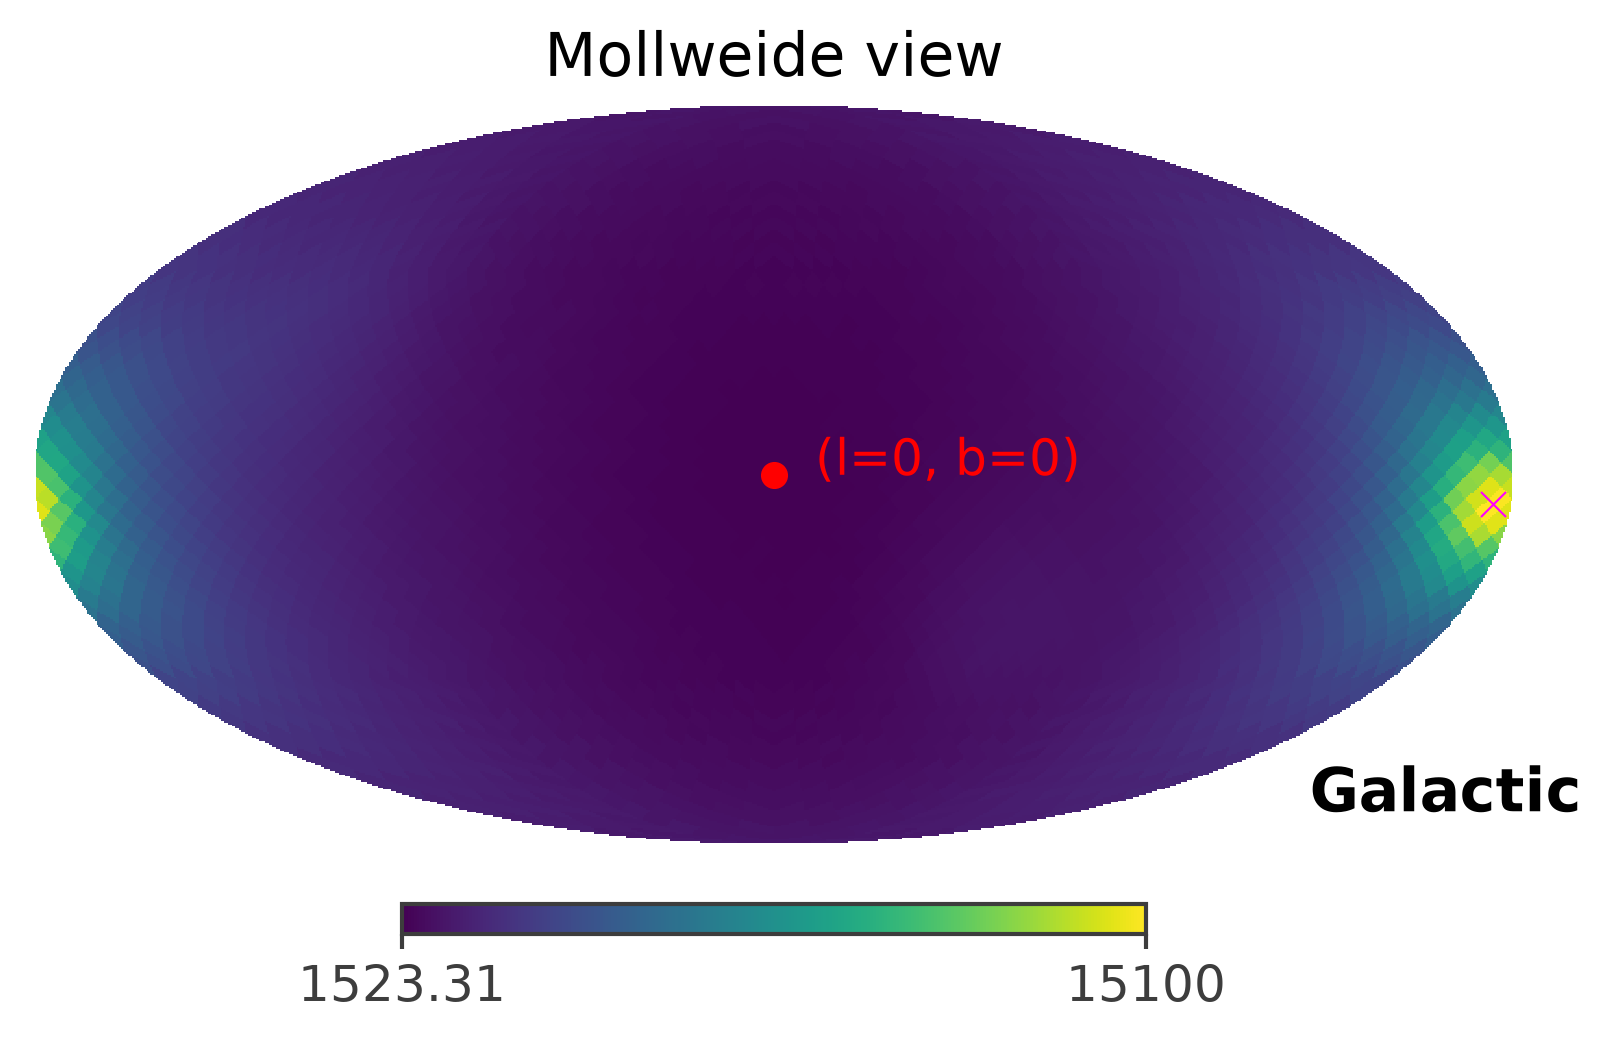

In [ ]:
ts_dc1.plot_ts(
    ts_results_dc1, 
    skycoord = coord, 
    save_plot = True)

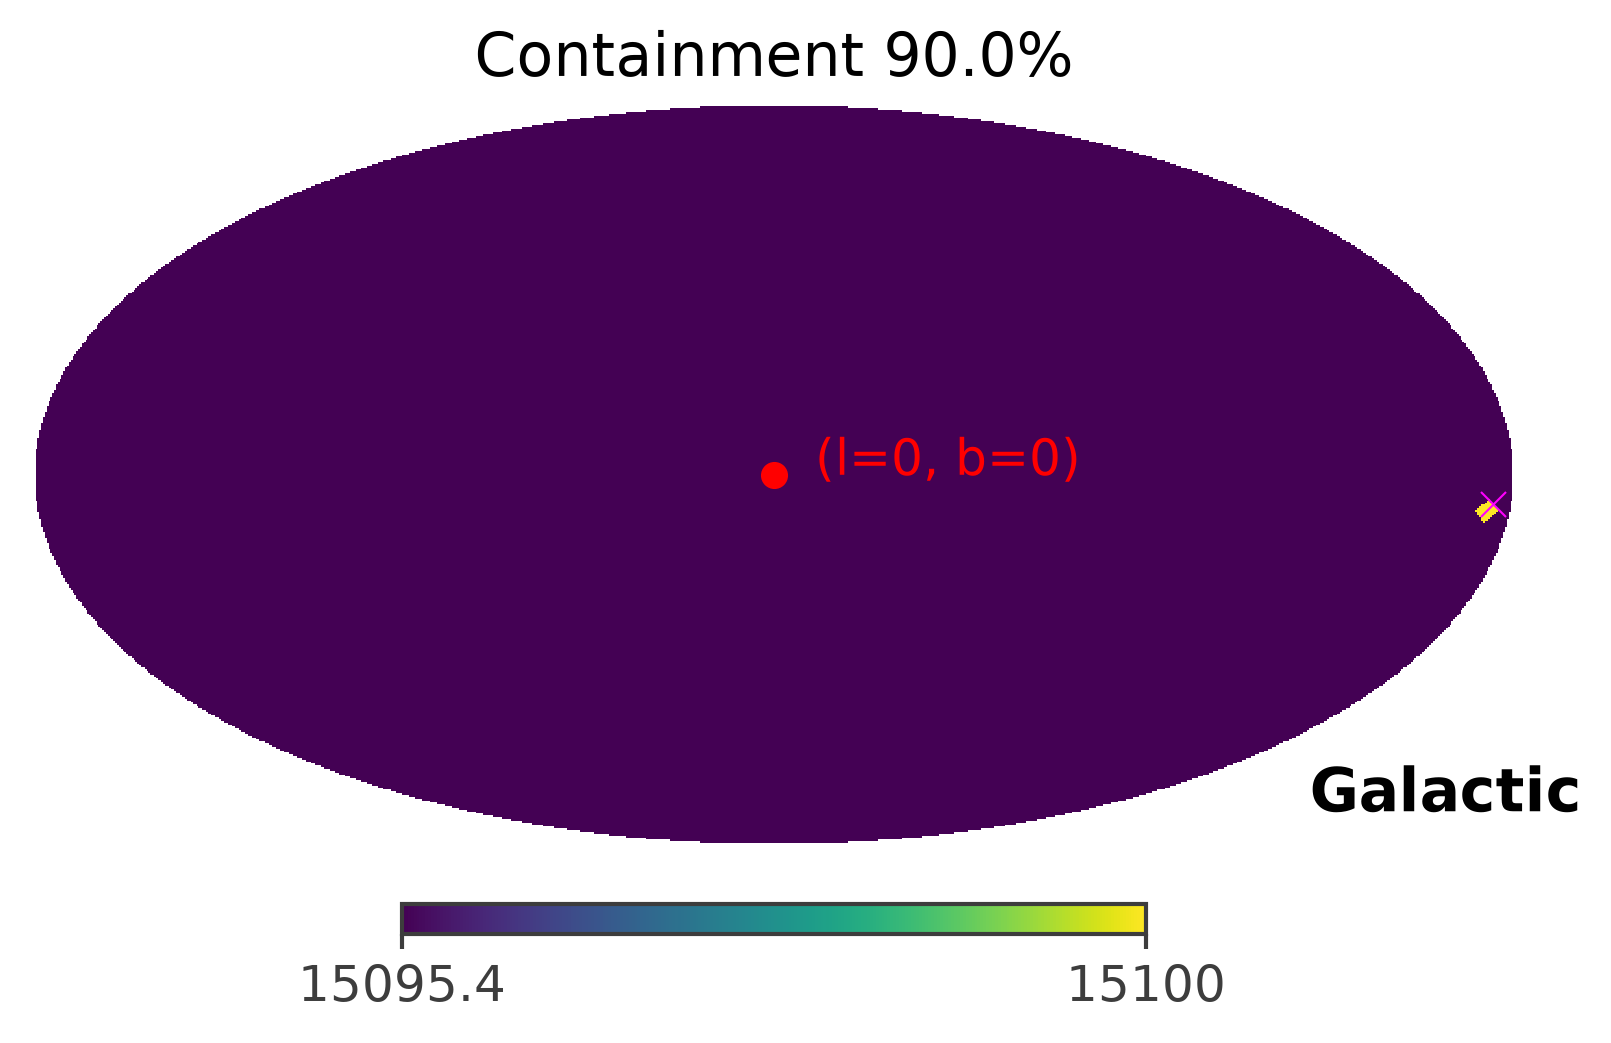

In [39]:
# plot the 90% confidence region
ts_dc1.plot_ts(ts_results_dc1, skycoord = coord, containment = 0.9)

****
***Using MOCSMAP***
****

In [40]:
# Here we will us MOCTSMap instead of FastTSMap, the parameters are same
moc_fit_dc1 = cp.MOCTSMap(data = data_dc1.data, 
                   bkg_model = bg_source_counts, 
                   response_path = data_galactic_response, 
                   orientation = None, # we don't need orientation since we are using the precomputed galactic reaponse
                   cds_frame = "galactic")

In [41]:
moc_ts, moc_uniq = moc_fit_dc1.fit(max_nside = 16, # this is the maximum nside of the final map
                               energy_channel = [4,5],  # The energy channel used to perform the fit.
                               spectrum = localization_spectrum)

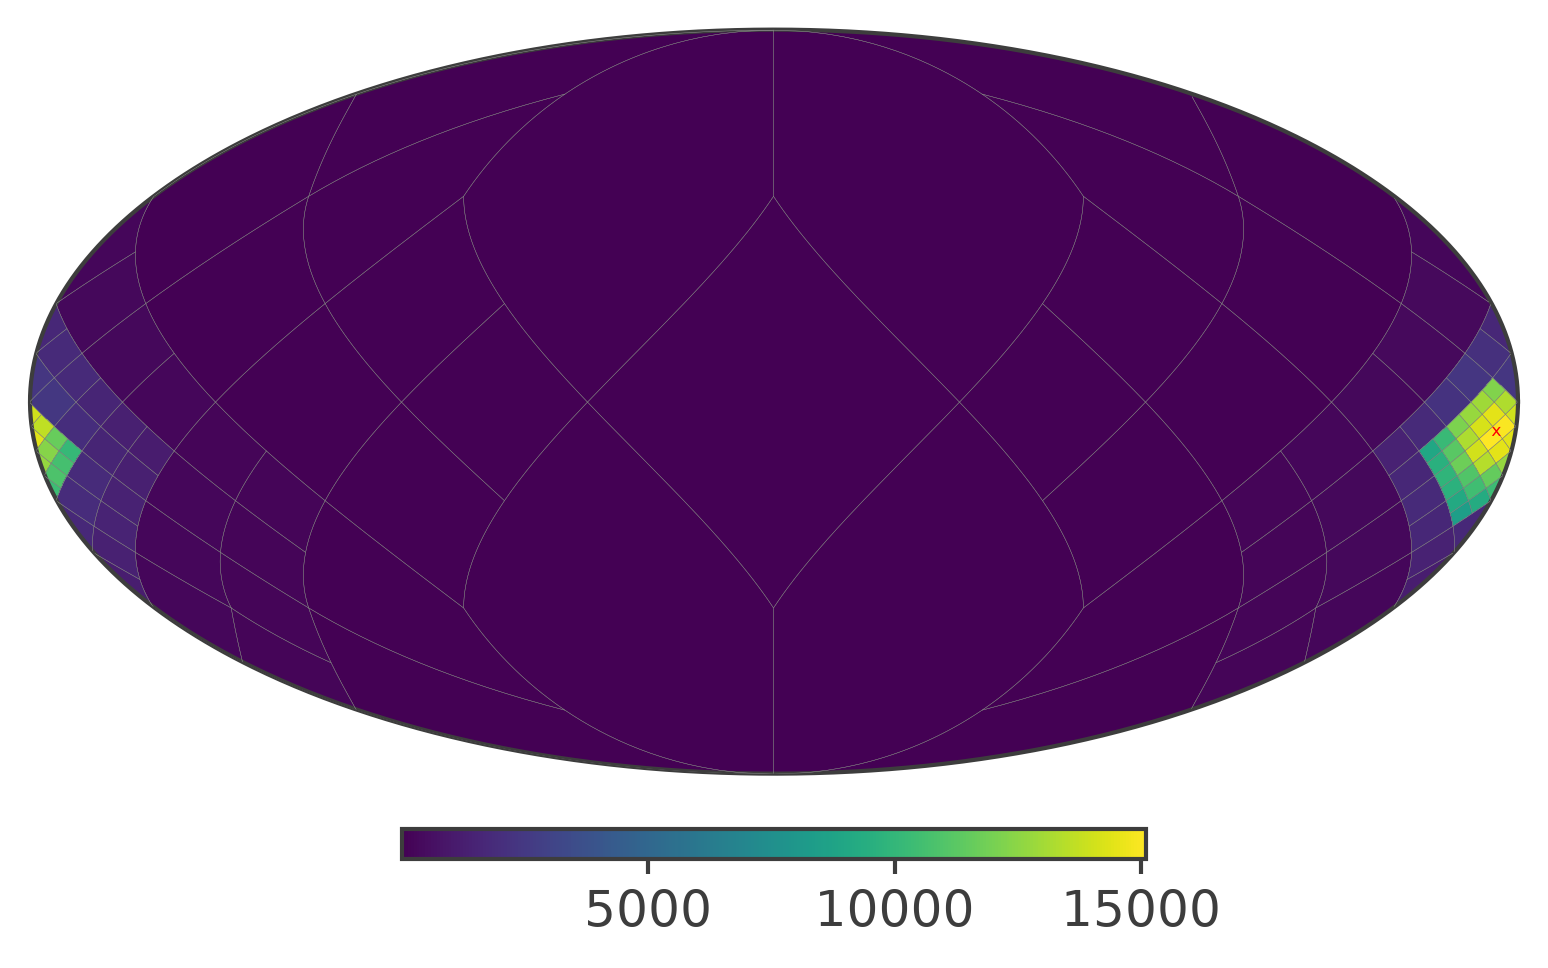

In [42]:
# plot the raw ts values
moc_fit_dc1.plot_ts(moc_ts, moc_uniq, dpi = 300, skycoord=coord)

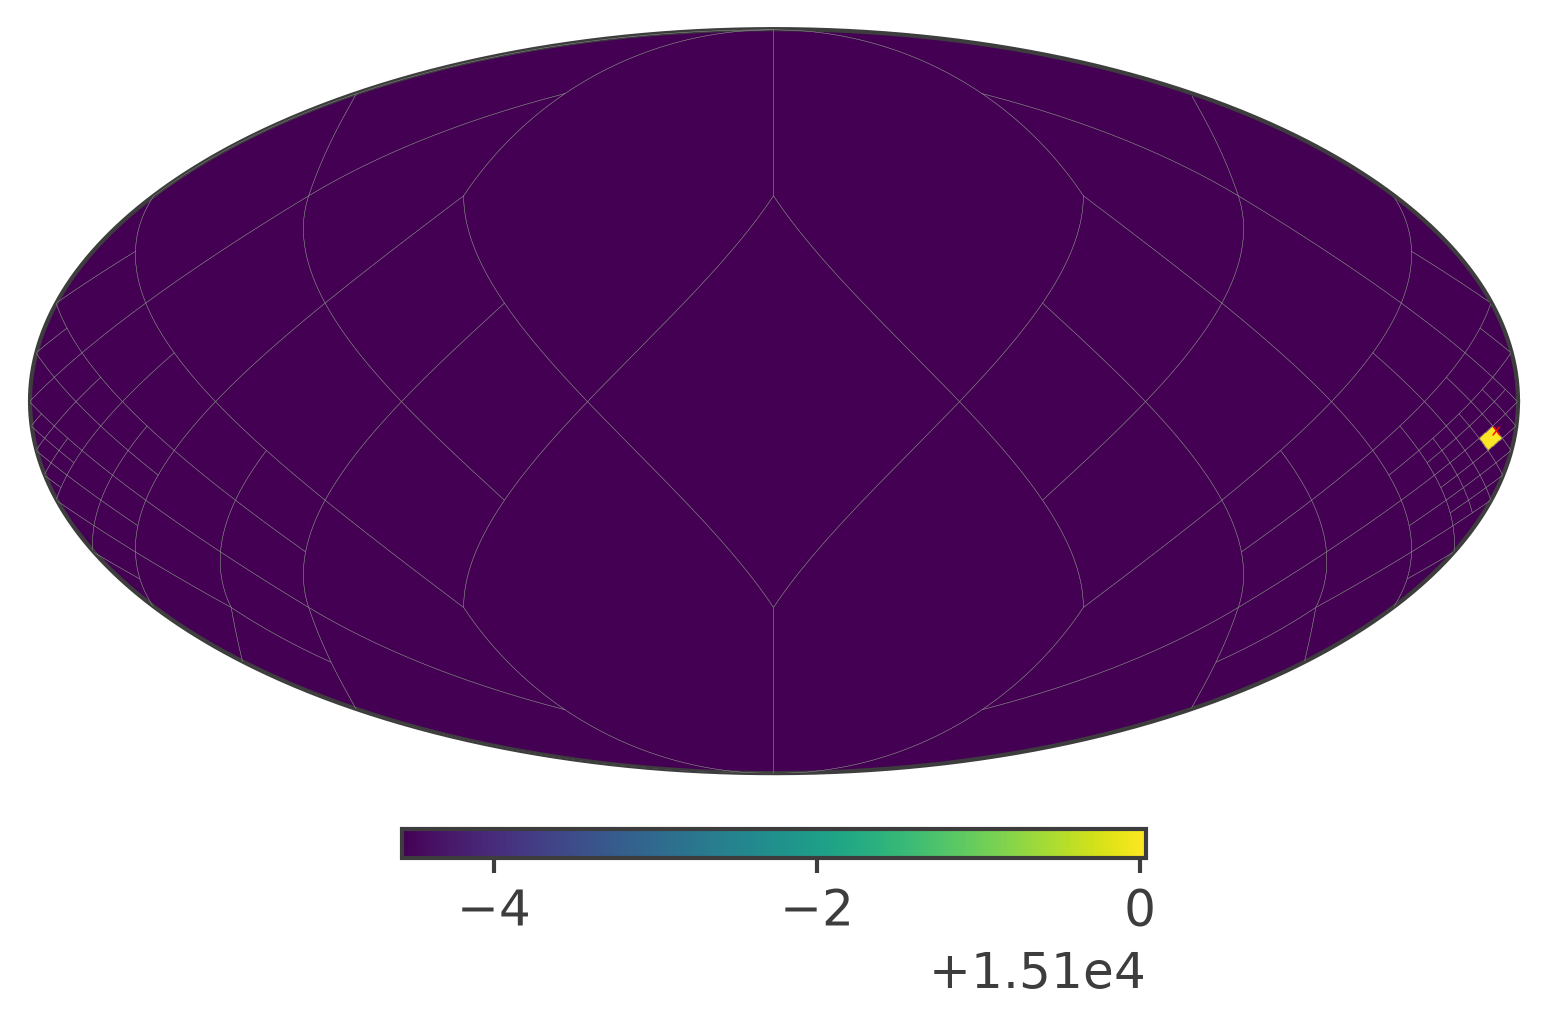

In [43]:
# plot the 90% confidence region
# You can see from the plot below, we recover the same 90% containment region as we did in Example 3
moc_fit_dc1.plot_ts(moc_ts, moc_uniq, dpi = 300, skycoord=coord, containment = 0.9)

***
Find the Maximum-TS Location
***

In [44]:
best_index_dc1 = int(np.nanargmax(moc_ts))
max_ts_dc1 = moc_ts[best_index_dc1]

print("Maximum TS:", max_ts_dc1)
print("Position in the results array:", best_index_dc1)

Maximum TS: 15100.036040374433
Position in the results array: 104


In [45]:
best_uniq_dc1 = moc_uniq[best_index_dc1]

print("Best-pixel UNIQ identifier:", best_uniq_dc1)

Best-pixel UNIQ identifier: 2615


In [46]:
best_nside_dc1, best_pixel_dc1 = hp.uniq2nest(best_uniq_dc1)

print("Pixel NSIDE:", best_nside_dc1)
print("Nested HEALPix pixel:", best_pixel_dc1)

Pixel NSIDE: 16
Nested HEALPix pixel: 1591


In [47]:
pixelization_dc1 = hp.HealpixBase(
    nside=int(best_nside_dc1),
    scheme="nested",
    coordsys="galactic",
)

recovered_coord_dc1 = pixelization_dc1.pix2skycoord(
    int(best_pixel_dc1)
)

print("Recovered longitude:", recovered_coord_dc1.l.deg, "deg")
print("Recovered latitude:", recovered_coord_dc1.b.deg, "deg")

Recovered longitude: 185.625 deg
Recovered latitude: -7.180755781458288 deg


<a id="toc-dc1-spectrum"></a>
### DC1 Goal 2 - Measure the Crab Spectrum

This section defines the DC1 Band source model and fits it using the
likelihood components prepared above. The recovered spectrum is then
compared with the known spectrum injected into the simulation.


#### Define the DC1 Source and Spectral Model

The Band model describes the Crab spectrum. Its initial values and allowed parameter ranges define the starting point and search region for the fit. The source position is fixed at the known Galactic coordinates of the Crab.

In [55]:
# Create the Band spectral model used for the DC1 fit.
spectrum_dc1 = Band()

# Set parameter bounds and initial optimizer step sizes.
# The beta upper bound remains below the alpha lower bound so that the
# optimizer stays within the mathematically valid Band-model region.
spectrum_dc1.alpha.min_value = -2.14
spectrum_dc1.alpha.max_value = 3.0

spectrum_dc1.beta.min_value = -5.0
spectrum_dc1.beta.max_value = -2.15

spectrum_dc1.xp.min_value = 1.0

spectrum_dc1.alpha.delta = 0.01
spectrum_dc1.beta.delta = 0.01

# Assign the initial spectral parameter values defined in the input section.
spectrum_dc1.alpha.value = dc1_alpha_initial
spectrum_dc1.beta.value = dc1_beta_initial
spectrum_dc1.xp.value = dc1_xp_initial.value
spectrum_dc1.K.value = dc1_K_initial.value
spectrum_dc1.piv.value = dc1_piv.value

# Assign the physical units of the energy and normalization parameters.
spectrum_dc1.xp.unit = dc1_xp_initial.unit
spectrum_dc1.K.unit = dc1_K_initial.unit
spectrum_dc1.piv.unit = dc1_piv.unit


# Define the Crab as a point source with a fixed position and Band spectrum.
source_dc1 = PointSource(
    "source",
    l=l_crab,
    b=b_crab,
    spectral_shape=spectrum_dc1,
)

# Optional: free the position parameters
# source_dc1.position.l.free = True
# source_dc1.position.b.free = True

# Package the single point source as the astrophysical model used by 3ML.
model_dc1 = Model(source_dc1)


The current value of the parameter beta (-2.0) was above the new maximum -2.15.


#### Run the Maximum-Likelihood Fit

3ML connects the source model to the COSI plugin and varies the free source and background parameters. The best-fit parameters are those that maximize the Poisson likelihood of the observed DC1 counts.

In [56]:
# Collect the COSI plugin in a 3ML DataList.
# Additional instruments or datasets could be added to this list.
plugins_dc1 = DataList(cosi_dc1)

# Build the joint-likelihood analysis by connecting the DC1 data plugin
# with the source model. The model already contains the initial parameter
# values, parameter bounds, and information about which parameters are free.
# This step configures the fit but does not run it.
like_dc1 = JointLikelihood(
    model_dc1,
    plugins_dc1,
    verbose=False,
)

# Run the maximum-likelihood fit. The optimizer starts from the initial
# values stored in model_dc1 and varies the free parameters within their
# allowed bounds to find the model that best describes the observed data.
_ = like_dc1.fit()


WARNING RuntimeWarning: invalid value encountered in power


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: invalid value encountered in power

The current value of the parameter beta (-2.0) was above the new maximum -2.15.


Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(7.84 +/- 0.16) x 10^-5,1 / (keV s cm2)
source.spectrum.main.Band.alpha,-1.8747 +/- 0.0030,
source.spectrum.main.Band.xp,5.24 -0.30 +0.32,keV
source.spectrum.main.Band.beta,-2.2110 +/- 0.0028,
total_background,(3.19967 +/- 0.00028) x 10,Hz


Correlation matrix:

1.00,0.46,-0.52,-0.16,-0.00
0.46,1.00,0.43,0.13,0.01
-0.52,0.43,1.00,-0.13,-0.01
-0.16,0.13,-0.13,1.00,-0.16
-0.00,0.01,-0.01,-0.16,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_dc1,-1709613872.5790007
total,-1709613872.5790007


Values of statistical measures:

,statistical measures
AIC,-3419227735.1577845
BIC,-3419227682.5085325


#### Validate the Recovered Spectrum

The injected spectrum represents the known spectral model used to simulate the
Crab data in MEGAlib. It is not fitted again. Instead, it is used as the
simulation truth and compared with the spectrum recovered by the likelihood fit.

The fit uncertainties and parameter correlations are propagated to the spectral
flux, allowing the recovered spectrum and its uncertainty band to be compared
with the injected spectrum.

#### Define the Injected Spectrum

In [ ]:
# Define the known Band spectrum originally injected into the simulation.
# This spectrum is not fitted; it is used as the simulation truth for comparison.

dc1_alpha_injected = -1.99
dc1_beta_injected = -2.32

# Convert the injected break-energy parameter into the peak-energy
# parameterization used by the 3ML Band model.
dc1_E0_injected = (
    531.0
    * (dc1_alpha_injected - dc1_beta_injected)
    * u.keV
)

dc1_xp_injected = (
    dc1_E0_injected
    * (dc1_alpha_injected + 2)
    / (dc1_alpha_injected - dc1_beta_injected)
)

# Define the injected pivot energy and normalization.
dc1_piv_injected = 100.0 * u.keV
dc1_K_injected = 7.56e-4 / u.cm / u.cm / u.s / u.keV

#### Build the Injected Band Model

In [58]:
# Create the Band model that represents the simulation truth.
spectrum_dc1_injected = Band()

# Set valid parameter bounds.
# These are not used for another fit, but keep the model parameters
# within the physically and mathematically valid Band-model region.
spectrum_dc1_injected.alpha.min_value = -2.14
spectrum_dc1_injected.alpha.max_value = 3.0
spectrum_dc1_injected.beta.min_value = -5.0
spectrum_dc1_injected.beta.max_value = -2.15
spectrum_dc1_injected.xp.min_value = 1.0

# Assign the known injected parameter values.
spectrum_dc1_injected.alpha.value = dc1_alpha_injected
spectrum_dc1_injected.beta.value = dc1_beta_injected
spectrum_dc1_injected.xp.value = dc1_xp_injected.value
spectrum_dc1_injected.K.value = dc1_K_injected.value
spectrum_dc1_injected.piv.value = dc1_piv_injected.value

# Assign the physical units required to evaluate the spectrum.
spectrum_dc1_injected.xp.unit = dc1_xp_injected.unit
spectrum_dc1_injected.K.unit = dc1_K_injected.unit
spectrum_dc1_injected.piv.unit = dc1_piv_injected.unit

The current value of the parameter beta (-2.0) was above the new maximum -2.15.


#### Extract the Fit Results and Propagate Uncertainties

The fit results contain the optimized parameters, their uncertainties, and their correlations. Propagating them through the Band function produces an uncertainty distribution for the recovered flux at each energy.

In [59]:
# Retrieve the results produced by the DC1 maximum-likelihood fit.

results_dc1 = like_dc1.results

# Display the best-fit values, uncertainties, correlation matrix,
# likelihood value, and statistical measures.
results_dc1.display()

# Collect the uncertainty distributions of the free source parameters.
# These distributions retain the uncertainties and correlations found
# during the fit.
parameters_dc1 = {
    parameter.name: results_dc1.get_variates(parameter.path)
    for parameter in (
        results_dc1.optimized_model["source"].parameters.values()
    )
    if parameter.free
}

# Propagate the fitted parameter uncertainties and correlations through
# the Band function. The result can be evaluated at different energies
# to obtain the fitted flux and its uncertainty interval.
spectrum_uncertainty_dc1 = results_dc1.propagate(
    results_dc1.optimized_model[
        "source"
    ].spectrum.main.shape.evaluate_at,
    **parameters_dc1,
)

# Display the optimized Crab source model.
print(results_dc1.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(7.84 +/- 0.16) x 10^-5,1 / (keV s cm2)
source.spectrum.main.Band.alpha,-1.8747 +/- 0.0030,
source.spectrum.main.Band.xp,5.24 -0.30 +0.32,keV
source.spectrum.main.Band.beta,-2.2110 +/- 0.0028,
total_background,(3.19967 +/- 0.00028) x 10,Hz


Correlation matrix:

1.00,0.46,-0.52,-0.16,-0.00
0.46,1.00,0.43,0.13,0.01
-0.52,0.43,1.00,-0.13,-0.01
-0.16,0.13,-0.13,1.00,-0.16
-0.00,0.01,-0.01,-0.16,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_dc1,-1709613872.5790007
total,-1709613872.5790007


Values of statistical measures:

,statistical measures
AIC,-3419227735.1577845
BIC,-3419227682.5085325


The current value of the parameter beta (-2.0) was above the new maximum -2.15.
The current value of the parameter beta (-2.0) was above the new maximum -2.15.
The current value of the parameter beta (-2.0) was above the new maximum -2.15.


  * source (point source):
    * position:
      * l:
        * value: 184.55746
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -5.78436
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Band:
          * K:
            * value: 7.841037552287853e-05
            * desc: Differential flux at the pivot energy
            * min_value: 1.0e-50
            * max_value: null
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * alpha:
            * value: -1.8747021699847433
            * desc: low-energy photon index
            * min_value: -2.14
            * max_value: 3.0
            * unit: ''
            * is_normalization: false
          * xp:
            * value: 5.236522944383875


#### Evaluate the Spectra and Prepare the Energy Bins

The fitted and injected spectra are evaluated on a smooth logarithmic energy grid for plotting. The measured-energy bin edges are retained separately for comparisons in detector count space.

In [60]:
# Create logarithmically spaced energy values between 100 keV and 10 MeV.
# These values will be used to evaluate and plot the spectral models.
# The final array contains numerical values expressed in keV.
energy = np.geomspace(
    100 * u.keV,
    10 * u.MeV,
).to_value(u.keV)

# Create empty arrays where the fitted flux, its uncertainty interval,
# and the known injected flux will be stored at each energy.
flux_lo_dc1 = np.zeros_like(energy)
flux_median_dc1 = np.zeros_like(energy)
flux_hi_dc1 = np.zeros_like(energy)
flux_injected_dc1 = np.zeros_like(energy)

# Evaluate the fitted and injected spectra at every energy.
for i, energy_value in enumerate(energy):

    # Evaluate the fitted spectrum while propagating the uncertainties
    # and correlations of its fitted parameters.
    fitted_flux = spectrum_uncertainty_dc1(energy_value)

    # Store the central fitted flux.
    flux_median_dc1[i] = fitted_flux.median

    # Store the lower and upper limits of the 68% uncertainty interval.
    # This interval is approximately equivalent to one standard deviation.
    flux_lo_dc1[i], flux_hi_dc1[i] = (
        fitted_flux.equal_tail_interval(cl=0.68)
    )

    # Evaluate the known spectrum originally injected into the simulation.
    # This provides the reference used to test how well the fit recovered it.
    flux_injected_dc1[i] = (
        spectrum_dc1_injected.evaluate_at(energy_value)
    )

# Extract the measured-energy bin edges used to bin the DC1 observation.
binned_energy_edges_dc1 = data_dc1.axes["Em"].edges.value

# Create empty arrays for the center and width of each energy bin.
binned_energy_dc1 = np.array([])
bin_sizes_dc1 = np.array([])

# Calculate the center and width of every measured-energy bin.
for i in range(len(binned_energy_edges_dc1) - 1):

    # Calculate the midpoint between the lower and upper bin edges.
    binned_energy_dc1 = np.append(
        binned_energy_dc1,
        (
            binned_energy_edges_dc1[i + 1]
            + binned_energy_edges_dc1[i]
        )
        / 2,
    )

    # Calculate the width of the energy bin.
    bin_sizes_dc1 = np.append(
        bin_sizes_dc1,
        (
            binned_energy_edges_dc1[i + 1]
            - binned_energy_edges_dc1[i]
        ),
    )

# Calculate the source counts predicted by the best-fit spectrum
# after folding it through the COSI detector response.
# This does not include the background expectation.
expectation_dc1 = response_dc1.expectation()

#### Compare the Recovered and Injected Flux

This plot compares the recovered spectral energy distribution and its 68% uncertainty interval with the known spectrum injected into the simulation.

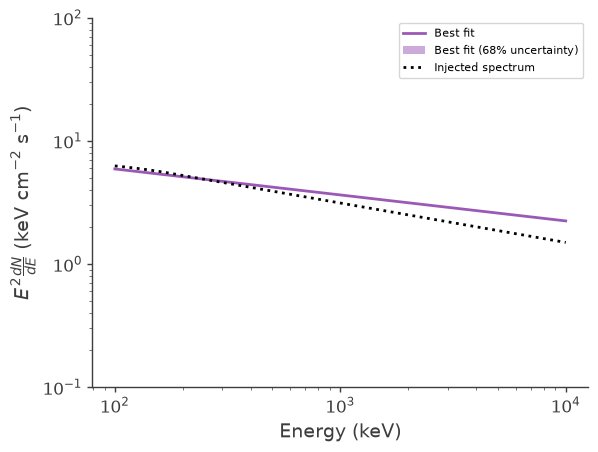

In [61]:
# Create the figure and plotting axes.

fig, ax = plt.subplots()

# Plot the median spectrum recovered by the fit.
# Multiplying by E^2 makes the spectral energy distribution easier to compare
# across a large energy range.
ax.plot(
    energy,
    energy**2 * flux_median_dc1,
    label="Best fit",
)

# Plot the 68% uncertainty region around the fitted spectrum.
ax.fill_between(
    energy,
    energy**2 * flux_lo_dc1,
    energy**2 * flux_hi_dc1,
    alpha=0.5,
    label="Best fit (68% uncertainty)",
)

# Plot the known spectrum originally injected into the simulation.
ax.plot(
    energy,
    energy**2 * flux_injected_dc1,
    color="black",
    linestyle=":",
    label="Injected spectrum",
)

# Use logarithmic axes because the energies and fluxes cover wide ranges.
ax.set_xscale("log")
ax.set_yscale("log")

# Label the physical quantities displayed on each axis.
ax.set_xlabel("Energy (keV)")
ax.set_ylabel(
    r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)"
)

# Set the visible range of the spectral energy distribution.
ax.set_ylim(0.1, 100)

# Display labels identifying the fitted and injected spectra.
ax.legend()

plt.show()

#### Compare Source-Only Counts

This comparison isolates the Crab component: the fitted spectrum folded through the detector response is compared with the source-only counts from the simulation. The background is excluded from both curves.

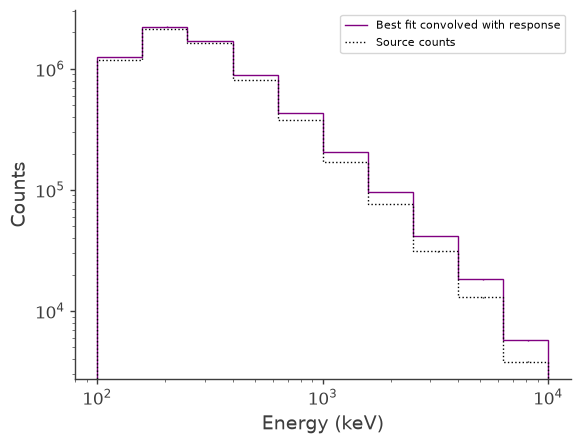

In [62]:
fig,ax = plt.subplots()

# Energy-bin centers/edges for the measured-energy axis
em_edges = data_dc1.axes["Em"].edges.value
em_centers = np.array([
    0.5 * (em_edges[i] + em_edges[i + 1])
    for i in range(len(em_edges) - 1)
])

# Project the expected counts and source counts onto the measured-energy axis
expected_em = expectation_dc1.project("Em").to_dense(copy=False).contents
source_em = dc1_source_counts.project("Em").to_dense(copy=False).contents

ax.stairs(
    expected_em,
    em_edges,
    color="purple",
    label="Best fit convolved with response",
)
ax.errorbar(
    em_centers,
    expected_em,
    yerr=np.sqrt(expected_em),
    color="purple",
    linewidth=0,
    elinewidth=1,
)

ax.stairs(
    source_em,
    em_edges,
    color="black",
    ls=":",
    label="Source counts",
)
ax.errorbar(
    em_centers,
    source_em,
    yerr=np.sqrt(source_em),
    color="black",
    linewidth=0,
    elinewidth=1,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

_ = ax.legend()

#### Compare Total Predicted and Observed Counts

This final validation adds the fitted background expectation back to the fitted Crab expectation. The resulting total prediction is compared with the complete simulated observation, which also contains both Crab and background counts.

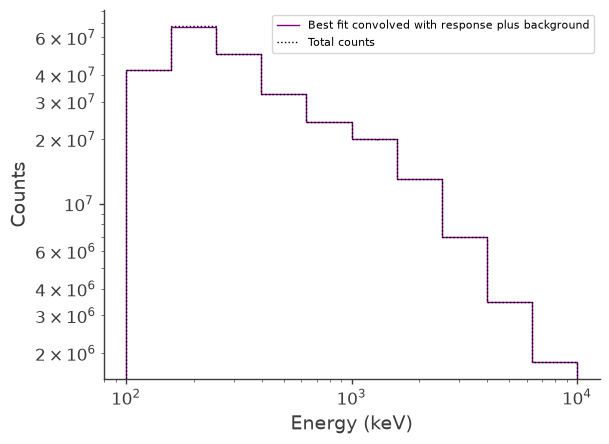

In [63]:
expectation_bkg = background_model.expectation(copy=True)

em_edges = data_dc1.axes["Em"].edges.value
em_centers = np.array([
    0.5 * (em_edges[i] + em_edges[i + 1])
    for i in range(len(em_edges) - 1)
])

expected_em = (
    expectation_dc1.project("Em").to_dense(copy=False).contents
    + expectation_bkg.project("Em").to_dense(copy=False).contents
)

observed_em = data_dc1.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots()

ax.stairs(
    expected_em,
    em_edges,
    color="purple",
    label="Best fit convolved with response plus background",
)
ax.errorbar(
    em_centers,
    expected_em,
    yerr=np.sqrt(expected_em),
    color="purple",
    linewidth=0,
    elinewidth=1,
)

ax.stairs(
    observed_em,
    em_edges,
    color="black",
    ls=":",
    label="Total counts",
)
ax.errorbar(
    em_centers,
    observed_em,
    yerr=np.sqrt(observed_em),
    color="black",
    linewidth=0,
    elinewidth=1,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()

<a id="toc-dc1-imaging"></a>
### DC1 Goal 3 - Image the Crab

This section reconstructs an image of the Crab from the DC1 observation. Long
file-handling and plotting implementations live in `src/dc2_analysis`; the
scientific choices and COSIpy workflow remain visible here.


#### Select the Imaging Energy Range

Choose whether to reconstruct one energy bin or the complete energy range. Both
options feed the same reconstruction chain below; only the selected data,
background, response, and model energy grid change.


In [64]:
# Choose the energy range used by the imaging analysis.
#
# "single_bin" reproduces the legacy DC1 energy-bin approach and is safe for
# this machine. "full_dataset" retains every energy bin but requires enough
# memory to load the complete Galactic response (approximately 24 GiB).

imaging_energy_mode = "single_bin"
imaging_energy_channel = 2

# Apply the same energy selection to the observation and background.
imaging_data_dc1, imaging_background_dc1 = select_imaging_data(
    data=data_dc1.data,
    background=bg_source_counts,
    energy_mode=imaging_energy_mode,
    energy_channel=imaging_energy_channel,
)

################################################################################
# In single-bin mode, this is equivalent to the manual selection used by the   #
# legacy COSIpy implementation in Data Challenge 1:                            #
#                                                                               #
#     dataset = analysis1.dataset.binned_data[:, ebin, :, :]                    #
#     background_model = background1.bg_model_reduced[ebin]                     #
#                                                                               #
# The modern histpy selection preserves the Em axis and its physical edges.    #
################################################################################


In [65]:
# Verify the data selection before preparing the matching response.
print("Imaging energy mode:", imaging_energy_mode)
print("Imaging data axes:", imaging_data_dc1.axes.labels)
print("Imaging data shape:", imaging_data_dc1.shape)
print("Imaging background shape:", imaging_background_dc1.shape)
print(
    "Selected measured-energy edges:",
    imaging_data_dc1.axes["Em"].edges,
)


Imaging energy mode: single_bin
Imaging data axes: ['Em' 'Phi' 'PsiChi']
Imaging data shape: (1, 36, 768)
Imaging background shape: (1, 36, 768)
Selected measured-energy edges: [251.189 398.107] keV


#### Prepare the Response for the Selected Energy Range

In single-bin mode, create or reuse a compact response containing only the
chosen incident- and measured-energy bins. In full-dataset mode, use the
original response directly and skip the reduction.


In [66]:
# Obtain the matching response path.
#
# In single-bin mode, the helper creates the compact response only when it does
# not already exist. In full-dataset mode, it returns the original response.
imaging_response_path = prepare_imaging_response(
    full_response_path=data_galactic_response,
    energy_mode=imaging_energy_mode,
    energy_channel=imaging_energy_channel,
    sky_chunk_size=8,
)

print("Selected response path:", imaging_response_path)
print(
    "Selected response size:",
    imaging_response_path.stat().st_size / 1024**2,
    "MiB",
)


Selected response path: /Users/maura/Documents/COSI/data-challenge-2/data/data-products/downloads/psr_gal_DC2_Ei2_Em2.h5
Selected response size: 162.03956604003906 MiB


#### Load and Validate the Selected Response

Load either the compact response or the complete response selected above, then
confirm that its measured-energy axis matches the observation and background.
Full-dataset mode should only be executed on a machine with sufficient memory.


In [67]:
# Load the selected response into memory.
# Warning: full-dataset mode loads the complete response.
image_response_dc1 = Histogram.open(imaging_response_path)

print("Imaging response axes:", image_response_dc1.axes.labels)
print("Imaging response shape:", image_response_dc1.shape)
print("Incident-energy edges:", image_response_dc1.axes["Ei"].edges)
print("Measured-energy edges:", image_response_dc1.axes["Em"].edges)


Imaging response axes: ['NuLambda' 'Ei' 'Em' 'Phi' 'PsiChi']
Imaging response shape: (768, 1, 1, 36, 768)
Incident-energy edges: [251.189 398.107] keV
Measured-energy edges: [251.189 398.107] keV


In [68]:
# Stop immediately if the data, background, and response energy bins differ.
energy_axis_checks = validate_imaging_energy_axes(
    data=imaging_data_dc1,
    background=imaging_background_dc1,
    response=image_response_dc1,
)

print(
    "Data and background Em edges match:",
    energy_axis_checks["data_background"],
)
print(
    "Data and response Em edges match:",
    energy_axis_checks["data_response"],
)


Data and background Em edges match: True
Data and response Em edges match: True


#### Assemble the Imaging Dataset

The selected observation, matching background, and reduced Galactic response are combined into the interface required by COSIpy image deconvolution.


In [69]:
# Combine the selected DC1 observation, background, and Galactic response
# into the data interface required by the image-deconvolution algorithm.

imaging_dataset_dc1 = DataIF_COSI_DC2.load(
    name=f"Crab_DC1_{imaging_energy_mode}",
    event_binned_data=imaging_data_dc1,
    dict_bkg_binned_data={
        "total_background": imaging_background_dc1
    },
    rsp=image_response_dc1,

    # The response is already expressed in Galactic coordinates.
    coordsys_conv_matrix=None,
)


#### Configure and Run the Deconvolution

The YAML file defines the initial all-sky model and Richardson–Lucy settings. COSIpy then initializes the reconstruction and updates the sky model iteratively.


In [70]:
parameters_file_path = "input_deconvolution.yml"

# Create the deconvolution controller and connect the selected dataset.
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([imaging_dataset_dc1])
image_deconvolution.read_parameterfile(parameters_file_path)

# Match the model energy grid to the selected response automatically.
# This keeps the same YAML template valid for single-bin and full-dataset modes.
model_energy_edges = (
    image_response_dc1.axes["Ei"].edges.to_value(u.keV).tolist()
)
initial_flux_values = [0.01] * (
    image_response_dc1.axes["Ei"].nbins
)

image_deconvolution.parameter[
    "model_definition:property:energy_edges:value"
] = model_energy_edges

image_deconvolution.parameter[
    "model_definition:initialization:parameter:value"
] = initial_flux_values

print("Model Ei edges:", model_energy_edges)
print("Number of model energy bins:", len(initial_flux_values))


Model Ei edges: [251.189, 398.107]
Number of model energy bins: 1


In [71]:
image_deconvolution.initialize()

In [72]:
%%time

image_deconvolution.run_deconvolution()

  0%|          | 0/150 [00:00<?, ?it/s]

CPU times: user 1.25 s, sys: 26.3 ms, total: 1.28 s
Wall time: 1.29 s


#### Inspect Reconstruction Diagnostics

These plots track the log-likelihood, acceleration factor, and fitted background normalization across iterations. They help assess convergence and the stability of the reconstruction.


In [73]:
print(image_deconvolution.results[0].keys())

dict_keys(['iteration', 'model', 'background_normalization', 'log-likelihood', 'accel_factor'])


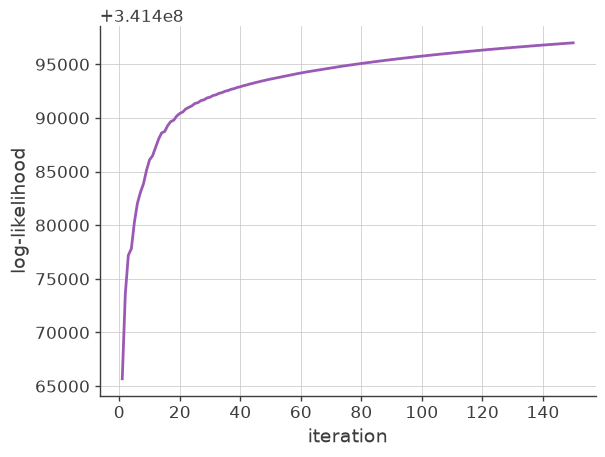

In [74]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['log-likelihood'])

plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.show()

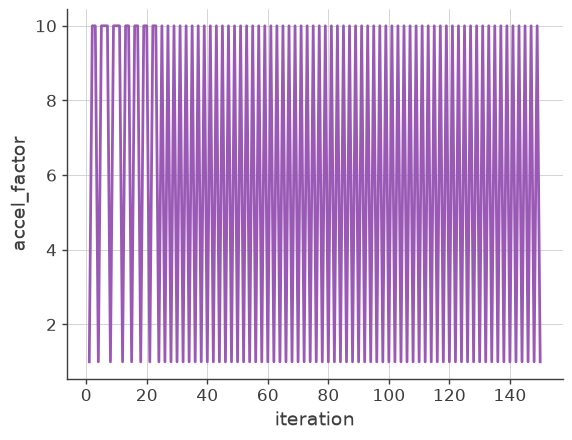

In [75]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['accel_factor'])

plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("accel_factor")
plt.show()


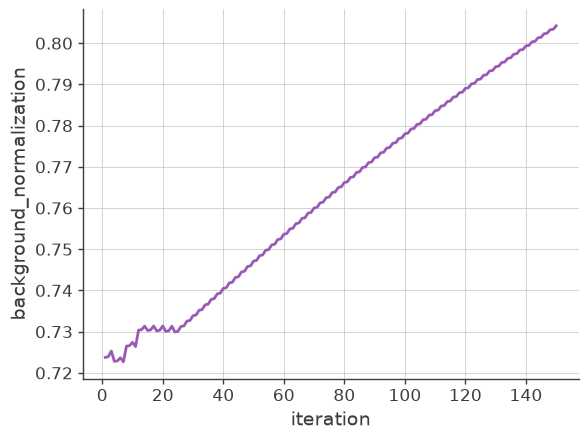

In [76]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['background_normalization']['total_background'])

plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("background_normalization")
plt.show()

#### Visualize the Reconstructed Crab Image

The reconstructed all-sky model can be displayed at selected iterations. The known Galactic position of the Crab may be marked for comparison.


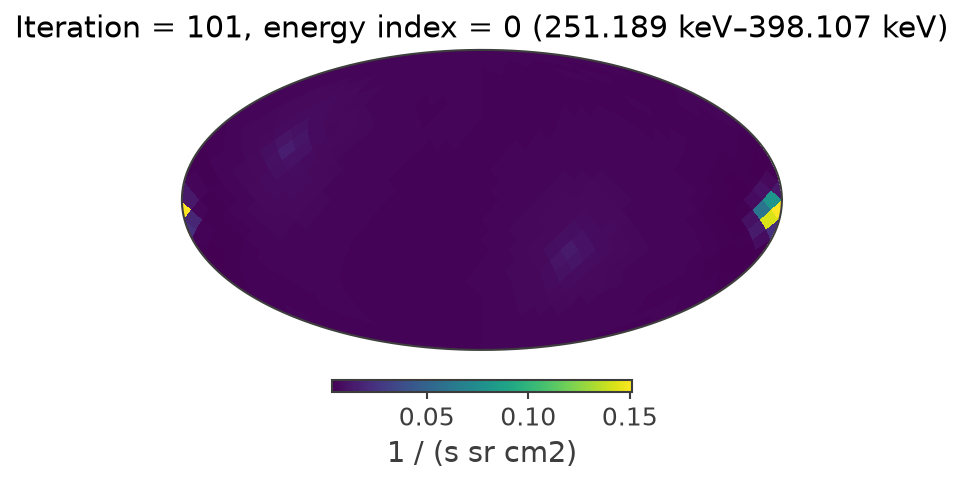

In [77]:
iteration = 100

plot_reconstructed_image(image_deconvolution.results[iteration])

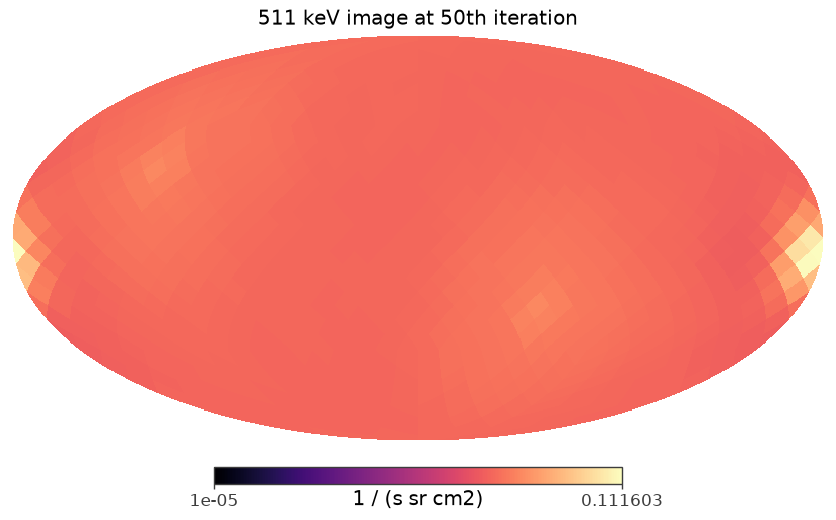

In [78]:
iteration_idx = 49

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

data = image[:,0]
data[data <= 0 * data.unit] = 1e-12 * data.unit

mollview(data, min = 1e-5, norm ='log', unit = str(data.unit), title = f'511 keV image at {iteration}th iteration', cmap = 'magma')

plt.show()